# Track Dataset — Data Cleaning & Preprocessing
> **Mục tiêu:** Chuẩn bị dataset sạch để train Machine Learning model phân loại `Class`  
> **Dataset:** `train.csv` — 14,396 rows × 18 columns  
> **Target:** `Class` (0–10, multi-class classification)

---
## Tổng quan vấn đề phát hiện

| # | Feature | Vấn đề | Tỷ lệ bị ảnh hưởng |
|---|---------|---------|---------------------|
| 1 | `Popularity` | Missing values | 2.31% (333 rows) |
| 2 | `key` | Missing values | 11.18% (1,609 rows) |
| 3 | `instrumentalness` | Missing values | 24.60% (3,541 rows) |
| 4 | `duration_in min/ms` | **Mixed units** — 14.4% giá trị ở dạng phút, 85.6% ở dạng milliseconds | 2,075 rows |
| 5 | `loudness` | 7 giá trị dương bất thường (loudness thông thường âm) | 0.05% |
| 6 | `speechiness`, `instrumentalness`, `liveness` | Outliers đáng kể theo IQR | 11–13% |
| 7 | `Class` | Imbalanced — Class 10 chiếm 27.5%, Class 3/4 chỉ ~2% | — |


## Step 1 — Import thư viện & Load data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Đang khai báo dữ liệu')

# Dữ liệu thô ban đầu
file_path = os.path.join("Data", "train.csv")

df = pd.read_csv(file_path)
print(f"Shape: {df.shape}")

df_beforeMixDuration = df.copy()

print('Khai báo thành công')


Đang khai báo dữ liệu
Shape: (14396, 18)
Khai báo thành công


## Step 2 — Kiểm tra tổng quan dataset

Xem dtype, missing values, và phân phối class target trước khi xử lý bất kỳ gì.


In [9]:
missing_df = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_df[missing_df['missing_count'] > 0])

print("\n" + "=" * 50)
print("DUPLICATES")
print("=" * 50)
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n" + "=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)
print(df['Class'].value_counts().sort_index())


DTYPES & MISSING VALUES
                    dtype  missing_count  missing_pct
Popularity        float64            333       2.3100
key               float64           1609      11.1800
instrumentalness  float64           3541      24.6000

DUPLICATES
Duplicate rows: 0

CLASS DISTRIBUTION
Class
0      500
1     1098
2     1018
3      322
4      310
5     1157
6     2069
7      461
8     1483
9     2019
10    3959
Name: count, dtype: int64


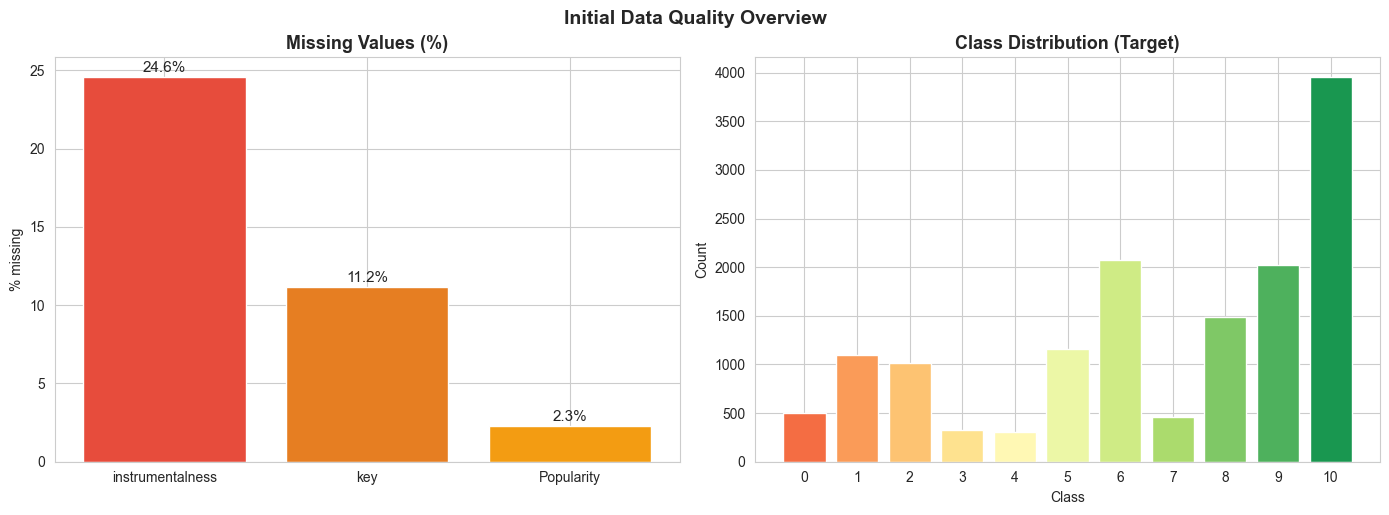

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values
missing_pct = (df.isnull().sum() / len(df) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
axes[0].bar(missing_pct.index, missing_pct.values, color=['#e74c3c','#e67e22','#f39c12'])
axes[0].set_title('Missing Values (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% missing')
for i, v in enumerate(missing_pct.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

# Class distribution
class_counts = df['Class'].value_counts().sort_index()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(class_counts)))
axes[1].bar(class_counts.index, class_counts.values, color=colors)
axes[1].set_title('Class Distribution (Target)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_xticks(class_counts.index)

plt.tight_layout()
plt.suptitle('Initial Data Quality Overview', y=1.02, fontsize=14, fontweight='bold')
plt.show()


## Step 3 — Xử lý `duration_in min/ms`: Mixed Units

### Vấn đề
Cột `duration_in min/ms` có **hai đơn vị khác nhau** trong cùng một cột:
- **~85.6% giá trị** ở dạng **milliseconds** (ms) — ví dụ: `204947.0`, `191956.0`
- **~14.4% giá trị** ở dạng **phút** (minutes) — ví dụ: `3.893`, `4.347`

Threshold phân biệt: giá trị < 100 được coi là phút (bài nhạc ngắn nhất thực tế ~0.5 phút, dài nhất ~30 phút).

### Phương pháp xử lý
**Convert toàn bộ về milliseconds**, sau đó đổi tên cột thành `duration_ms` cho rõ ràng.

Values in milliseconds : 12,321 (85.6%)
Values in minutes      : 2,075 (14.4%)


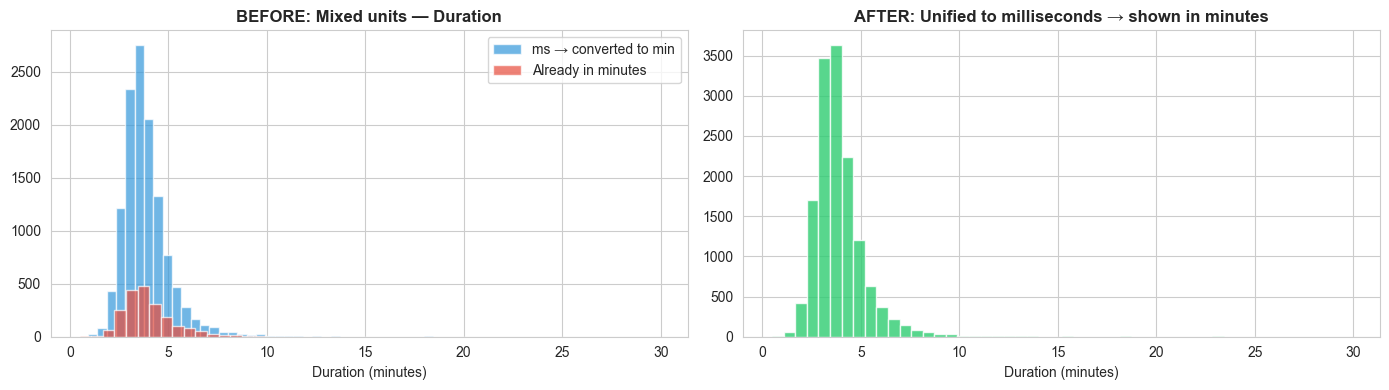


✅ duration_ms: min=0.50 min, max=29.89 min, mean=3.92 min


In [11]:
# Visualize mixed units BEFORE fix
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mask_minutes = df['duration_in min/ms'] < 100
mask_ms = df['duration_in min/ms'] >= 100

axes[0].hist(df.loc[mask_ms, 'duration_in min/ms'] / 1000 / 60, bins=50, 
             color='#3498db', alpha=0.7, label='ms → converted to min')
axes[0].hist(df.loc[mask_minutes, 'duration_in min/ms'], bins=50, 
             color='#e74c3c', alpha=0.7, label='Already in minutes')
axes[0].set_title('BEFORE: Mixed units — Duration', fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].legend()

print(f"Values in milliseconds : {mask_ms.sum():,} ({mask_ms.sum()/len(df)*100:.1f}%)")
print(f"Values in minutes      : {mask_minutes.sum():,} ({mask_minutes.sum()/len(df)*100:.1f}%)")

# FIX: Convert minutes → milliseconds
df['duration_in min/ms'] = df['duration_in min/ms'].apply(
    lambda x: x * 60 * 1000 if x < 100 else x
)
df.rename(columns={'duration_in min/ms': 'duration_ms'}, inplace=True)

# Visualize AFTER
axes[1].hist(df['duration_ms'] / 1000 / 60, bins=50, color='#2ecc71', alpha=0.8)
axes[1].set_title('AFTER: Unified to milliseconds → shown in minutes', fontweight='bold')
axes[1].set_xlabel('Duration (minutes)')

plt.tight_layout()
plt.show()

print(f"\n✅ duration_ms: min={df['duration_ms'].min()/60000:.2f} min, "
      f"max={df['duration_ms'].max()/60000:.2f} min, "
      f"mean={df['duration_ms'].mean()/60000:.2f} min")


In [12]:
df.head(10)

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0000,0.3340,0.5360,9.0000,-6.6490,0,0.0381,0.3780,NaN,0.1060,0.2350,152.4290,204947.0000,4,9
1,2,The Black Keys,Howlin' for You,67.0000,0.7250,0.7470,11.0000,-5.5450,1,0.0876,0.0272,0.0468,0.1040,0.3800,132.9210,191956.0000,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.5840,0.8040,7.0000,-6.0940,1,0.0619,0.0010,0.6350,0.2840,0.6350,159.9530,161037.0000,4,10
3,4,Detroit Blues Band,Missing You,12.0000,0.5150,0.3080,NaN,-14.7110,1,0.0312,0.9070,0.0213,0.3000,0.5010,172.4720,298093.0000,3,2
4,5,Coast Contra,My Lady,48.0000,0.5650,0.7770,6.0000,-5.0960,0,0.2490,0.1830,NaN,0.2110,0.6190,88.3110,254145.0000,4,5
5,6,Beck,Fuckin With My Head (Mountain Dew Rock),38.0000,0.6570,0.8130,7.0000,-7.8610,1,0.2160,0.0083,0.0492,0.2080,0.5890,82.0350,219587.0000,4,10
6,7,Shadow and Light,Blue,11.0000,0.6580,0.4310,1.0000,-12.7180,0,0.0300,0.6150,0.2920,0.0902,0.5280,132.0450,233636.0000,5,0
7,8,Within The Ruins,Devil In Me,45.0000,0.4410,0.9940,7.0000,-2.9340,1,0.2390,0.0001,0.0001,0.3820,0.0478,139.9310,213125.0000,4,8
8,9,Crazy Cavan,My Little Sister Gotta Motorbike,38.0000,0.4460,0.8160,9.0000,-9.7620,1,0.0766,0.3180,NaN,0.3390,0.7180,183.6960,165293.0000,4,10
9,10,Day Sulan,Bailar,58.0000,0.8520,0.5350,7.0000,-5.9400,0,0.0896,0.4390,0.0001,0.2460,0.4830,103.0070,205056.0000,4,5


In [15]:
df.describe()

,Id,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,Class
count,14396.0000,14063.0000,14396.0000,14396.0000,12787.0000,14396.0000,14396.0000,14396.0000,14396.0000,10855.0000,14396.0000,14396.0000,14396.0000,14396.0000,14396.0000,14396.0000
mean,7198.5000,44.5252,0.5431,0.6624,5.9538,-7.9016,0.6402,0.0802,0.2467,0.1781,0.1958,0.4864,122.6954,235223.2953,3.9244,6.6957
std,4155.9116,17.4189,0.1655,0.2360,3.2000,4.0559,0.4799,0.0852,0.3109,0.3043,0.1593,0.2395,29.5385,84372.9911,0.3595,3.2062
min,1.0000,1.0000,0.0596,0.0012,1.0000,-39.9520,0.0000,0.0225,0.0000,0.0000,0.0119,0.0215,30.5570,30099.0000,1.0000,0.0000
25%,3599.7500,33.0000,0.4320,0.5080,3.0000,-9.5380,0.0000,0.0348,0.0043,0.0001,0.0973,0.2990,99.7990,187333.0000,4.0000,5.0000
50%,7198.5000,44.0000,0.5450,0.6990,6.0000,-7.0135,1.0000,0.0471,0.0814,0.0039,0.1290,0.4805,120.0600,219800.5000,4.0000,8.0000
75%,10797.2500,56.0000,0.6580,0.8610,9.0000,-5.1620,1.0000,0.0831,0.4323,0.2010,0.2560,0.6720,141.9882,262455.0000,4.0000,10.0000
max,14396.0000,100.0000,0.9890,1.0000,11.0000,-0.1010,1.0000,0.9550,0.9960,0.9960,0.9920,0.9860,217.4160,1793160.0000,5.0000,10.0000


## Step 4 — Xử lý `loudness`: Giá trị dương bất thường

### Vấn đề
Loudness được đo bằng **dB (decibels)**, luôn là **số âm hoặc 0** (0 dB là mức tối đa).  
Dataset có **7 giá trị dương** (0.1 đến 1.342) — rõ ràng là lỗi dữ liệu.

### Phương pháp xử lý
**Đổi dấu** thành âm, 7 giá trị này nằm trong khoảng (0, 1.4), về mặt giá trị tuyệt đối hoàn toàn hợp lý cho loudness 
Đây là cách đơn giản và có ý nghĩa nhất thay vì xoá hoặc impute.


In [20]:
# Trước khi xử lý
print("Loudness > 0 BEFORE fix:")
print(df[df['loudness'] > 0][['Id', 'loudness']])

# FIX: Chuyển các giá trị dương thành giá trị âm
df.loc[df['loudness'] > 0, 'loudness'] = -df.loc[df['loudness'] > 0, 'loudness']

print(f"\n Loudness range after fix: [{df['loudness'].min():.3f}, {df['loudness'].max():.3f}]")
print(f"   Values > 0 remaining: {(df['loudness'] > 0).sum()}")


Loudness > 0 BEFORE fix:
Empty DataFrame
Columns: [Id, loudness]
Index: []

 Loudness range after fix: [-39.952, -0.101]
   Values > 0 remaining: 0


## Step 5 — Xử lý Missing Values

### Tóm tắt 3 cột bị missing:

| Feature | % Missing | Phân phối | Phương pháp | Lý do |
|---------|-----------|-----------|-------------|-------|
| `Popularity` | 2.31% | Phân phối gần normal (mean≈44.5) | **Median imputation** | Missing ít, median robust với outlier hơn mean |
| `key` | 11.18% | Categorical (integer 1–11) | **Mode imputation** | Biến categorical — dùng giá trị phổ biến nhất |
| `instrumentalness` | 24.60% | Lệch phải nặng (median≈0.004, nhiều bài = 0) | **Median imputation** | Phân phối skewed — median thể hiện đúng trung tâm, tránh bị kéo bởi outlier |

> ⚠️ **Lưu ý `instrumentalness`:** Missing 24.6% là tỷ lệ đáng kể.  
> Một phương án nâng cao là dùng **KNN Imputer** hoặc **IterativeImputer** dựa trên các feature liên quan (acousticness, energy...).  
> Ở đây chọn median vì đơn giản, interpretable và không leak thông tin cross-validation.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# BEFORE distributions
for ax, col in zip(axes, ['Popularity', 'key', 'instrumentalness']):
    ax.hist(df[col].dropna(), bins=30, color='#3498db', alpha=0.7, edgecolor='white')
    ax.axvline(df[col].median(), color='red', linestyle='--', label=f'Median={df[col].median():.2f}')
    ax.axvline(df[col].mean(), color='orange', linestyle='--', label=f'Mean={df[col].mean():.2f}')
    ax.set_title(f'{col} (before impute)\nmissing: {df[col].isnull().sum()}', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# FIX: Impute missing values
pop_median = df['Popularity'].median()
key_mode   = df['key'].mode()[0]
instr_median = df['instrumentalness'].median()

df['Popularity']        = df['Popularity'].fillna(pop_median)
df['key']               = df['key'].fillna(key_mode)
df['instrumentalness']  = df['instrumentalness'].fillna(instr_median)

# Convert key back to int after fillna
df['key'] = df['key'].astype(int)

print(f"✅ Popularity       — filled {333} NaN  → median = {pop_median}")
print(f"✅ key              — filled {1609} NaN → mode   = {int(key_mode)}")
print(f"✅ instrumentalness — filled {3541} NaN → median = {instr_median:.6f}")
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")


## Step 6 — Xử lý Outliers

### Phân tích outliers theo IQR:

| Feature | % Outliers | Quyết định |
|---------|-----------|------------|
| `speechiness` | 11.34% | **Giữ nguyên** — nhiều bài rap/spoken word có speechiness cao là hợp lệ |
| `instrumentalness` | 13.48% | **Giữ nguyên** — nhạc instrumental thực sự có giá trị gần 1.0 |
| `liveness` | 5.33% | **Giữ nguyên** — live recording thực sự tồn tại |
| `loudness` | 4.50% | **Winsorize tại 1st–99th percentile** — một số track bất thường rất nhỏ/rất to |
| `duration_ms` | *(kiểm tra)* | **Winsorize** — loại các track cực ngắn (<30s) hoặc cực dài (>1h) |

### Lý do dùng Winsorizing thay vì xóa:
- **Không mất dữ liệu** — hàng được giữ lại, chỉ clip giá trị cực đoan
- **Phù hợp cho ML** — model không bị ảnh hưởng bởi giá trị cực đoan mà thực chất là noise
- Với các feature như `speechiness`, `liveness`, `instrumentalness`: outlier có ý nghĩa âm nhạc thực sự → **không xử lý**


In [ ]:
from scipy.stats import mstats

def winsorize_col(df, col, lower=0.01, upper=0.99):
    """Clip giá trị về [lower_pct, upper_pct] percentile"""
    lo = df[col].quantile(lower)
    hi = df[col].quantile(upper)
    before_min, before_max = df[col].min(), df[col].max()
    df[col] = df[col].clip(lo, hi)
    affected = ((df[col] == lo) | (df[col] == hi)).sum()
    print(f"{col:20s} | before [{before_min:.3f}, {before_max:.3f}] "
          f"→ after [{lo:.3f}, {hi:.3f}] | clipped: {affected} rows")
    return df

cols_to_winsorize = ['loudness', 'duration_ms', 'tempo']
print("Winsorizing (1st–99th percentile):")
print("-" * 75)
for col in cols_to_winsorize:
    df = winsorize_col(df, col)

# Visualize key outlier features (before/after implicitly shown by dist)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feature_pairs = [
    ('speechiness', '#9b59b6'),
    ('instrumentalness', '#1abc9c'),
    ('liveness', '#e67e22'),
    ('loudness', '#e74c3c'),
    ('duration_ms', '#3498db'),
    ('tempo', '#2ecc71'),
]
for ax, (col, color) in zip(axes.flatten(), feature_pairs):
    ax.hist(df[col], bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions After Cleaning', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Step 7 — Xử lý Categorical & Structural Features

### `key` và `mode`
- `key` (0–11): Mang tính **cyclical** (C = 0, C# = 1, ... B = 11, rồi lại về C).  
  → **Cyclical encoding** (sin/cos transform) để model hiểu C và B là gần nhau.
- `mode` (0/1): Binary, đã đúng format — giữ nguyên.

### Drop columns không cần thiết
- `Id`: Chỉ là index, không có predictive power.
- `Artist Name`, `Track Name`: Text features — cần NLP riêng; drop cho ML pipeline cơ bản.


In [ ]:
# Cyclical encoding cho 'key' (0–11 note scale)
df['key_sin'] = np.sin(2 * np.pi * df['key'] / 12)
df['key_cos'] = np.cos(2 * np.pi * df['key'] / 12)

# Visualize cyclical encoding
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(12), df.groupby('key')['key'].count(), color='#3498db')
axes[0].set_title('Key distribution (original 0–11)', fontweight='bold')
axes[0].set_xlabel('Key (0=C, 1=C#, ..., 11=B)')

axes[1].scatter(df['key_sin'], df['key_cos'], 
                c=df['key'], cmap='hsv', alpha=0.3, s=5)
axes[1].set_title('Key after Cyclical Encoding (sin/cos)', fontweight='bold')
axes[1].set_xlabel('key_sin')
axes[1].set_ylabel('key_cos')
axes[1].set_aspect('equal')
circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--', linewidth=1)
axes[1].add_patch(circle)

plt.tight_layout()
plt.show()

# Drop unneeded columns
df.drop(columns=['Id', 'Artist Name', 'Track Name', 'key'], inplace=True)
print(f"✅ Dropped: Id, Artist Name, Track Name, key (replaced by key_sin, key_cos)")
print(f"\nFinal columns ({len(df.columns)}): {df.columns.tolist()}")


## Step 8 — Tổng kết & Đánh giá kết quả

### ✅ Checklist các vấn đề đã xử lý

| # | Vấn đề | Phương pháp | Kết quả |
|---|--------|-------------|---------|
| 1 | `Popularity` missing 2.31% | Median imputation | ✅ 0 missing |
| 2 | `key` missing 11.18% | Mode imputation | ✅ 0 missing |
| 3 | `instrumentalness` missing 24.60% | Median imputation | ✅ 0 missing |
| 4 | `duration_in min/ms` mixed units | Convert phút → ms, rename `duration_ms` | ✅ Unified units |
| 5 | `loudness` 7 giá trị dương | Negate (đổi dấu) | ✅ Tất cả ≤ 0 |
| 6 | `loudness`, `duration_ms`, `tempo` outliers | Winsorize 1–99th pct | ✅ Clipped |
| 7 | `key` cyclical nature | Sin/Cos encoding | ✅ `key_sin`, `key_cos` |
| 8 | Non-predictive columns | Drop `Id`, `Artist Name`, `Track Name` | ✅ Removed |

### ⚠️ Lưu ý & Bước tiếp theo

1. **Class Imbalance**: Class 10 chiếm 27.5%, Class 3/4 chỉ ~2%.  
   → Cân nhắc **SMOTE**, **class_weight='balanced'**, hoặc **stratified sampling** khi train.

2. **`instrumentalness` imputation**: 24.6% missing là nhiều.  
   → Nếu cần accuracy cao hơn, thử **KNNImputer** hoặc **IterativeImputer**.

3. **Feature Scaling**: Chưa scale — cần **StandardScaler** hoặc **MinMaxScaler** trước khi dùng distance-based models (SVM, KNN, Logistic Regression).

4. **`speechiness`, `liveness`, `instrumentalness`**: Outliers giữ nguyên vì có ý nghĩa âm nhạc thực tế.


In [ ]:
print("=" * 55)
print("FINAL DATASET SUMMARY")
print("=" * 55)
print(f"Shape       : {df.shape}")
print(f"Missing     : {df.isnull().sum().sum()} values")
print(f"Duplicates  : {df.duplicated().sum()} rows")
print(f"\nDtypes:")
print(df.dtypes)
print(f"\nDescribe:")
df.describe().round(3)


In [ ]:
# Correlation heatmap of final features
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap (Final Clean Dataset)', 
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [ ]:
# Save cleaned dataset
df.to_csv('train_cleaned.csv', index=False)
print("✅ Saved: train_cleaned.csv")
print(f"   Shape: {df.shape}")
